In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

# Load the Mumbai station data
df = pd.read_csv('BandraKurlaComplexMumbaiIITM.csv')  # change path if needed
# Renaming 'From Date' to 'DateTime' as it seems to be the intended time column
df['DateTime'] = pd.to_datetime(df['From Date'], errors='coerce', format='mixed') # Corrected column name and added error handling
df = df.sort_values('DateTime').set_index('DateTime')

# Use only pollutant columns (multivariate)
cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'SO2']
data = df[cols].ffill()  # forward-fill missing values using the recommended method

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (24620, 7)


,PM2.5,PM10,NO,NO2,NOx,NH3,SO2
DateTime,,,,,,,
2021-01-01 00:00:00,147.26,175.93,16.23,61.72,45.30,79.76,4.68
2021-01-01 00:15:00,145.37,173.96,16.88,61.50,45.75,79.01,18.49
2021-01-01 00:30:00,156.71,186.12,22.71,62.99,51.15,84.96,17.62
2021-01-01 00:45:00,171.18,205.41,16.55,59.13,44.19,77.83,18.14
2021-01-01 01:00:00,183.17,219.31,20.39,59.87,47.66,81.63,18.69


In [ ]:
# ========================= STEP 5.2: PREPROCESSING & SEQUENCE CREATION =========================
# Scale the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create sequences (lookback = 24 hours → predict next hour)
def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, 0])  # target = PM2.5 (column 0)
    return np.array(X), np.array(y)

seq_length = 24
X, y = create_sequences(scaled_data, seq_length)

# Train-test split (80-20, no shuffle for time series)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Training shape:", X_train.shape, y_train.shape)

Training shape: (19676, 24, 7) (19676,)


In [ ]:
# ========================= STEP 5.3: BUILD & TRAIN LSTM MODEL =========================
model = Sequential()
model.add(LSTM(100, return_sequences=True, input_shape=(seq_length, X.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(100, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()

history = model.fit(X_train, y_train, epochs=20, batch_size=64,
                    validation_data=(X_test, y_test), verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 100)        │        43,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,701 (502.74 KB)

 Trainable params: 128,701 (502.74 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - loss: 0.0012 - val_loss: 9.9818e-04
Epoch 2/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - loss: 6.5970e-04 - val_loss: 6.8828e-04
Epoch 3/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - loss: 5.2130e-04 - val_loss: 6.0921e-04
Epoch 4/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 4.4059e-04 - val_loss: 4.8381e-04
Epoch 5/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 4.3224e-04 - val_loss: 4.4428e-04
Epoch 6/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - loss: 4.1321e-04 - val_loss: 4.5062e-04
Epoch 7/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 4.0839e-04 - val_loss: 4.7751e-04
Epoch 8/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - loss: 4.0870e-04 - val_loss: 4.7684e-04
Epoch 9/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - loss: 3.9463e-04 - val_loss: 5.8871e-04
Epoch 10/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - loss: 4.1849e-04 - val_loss: 4.8342e-04
Epoch 11/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 13

154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
MAE: 5.58 µg/m³
RMSE: 11.77 µg/m³


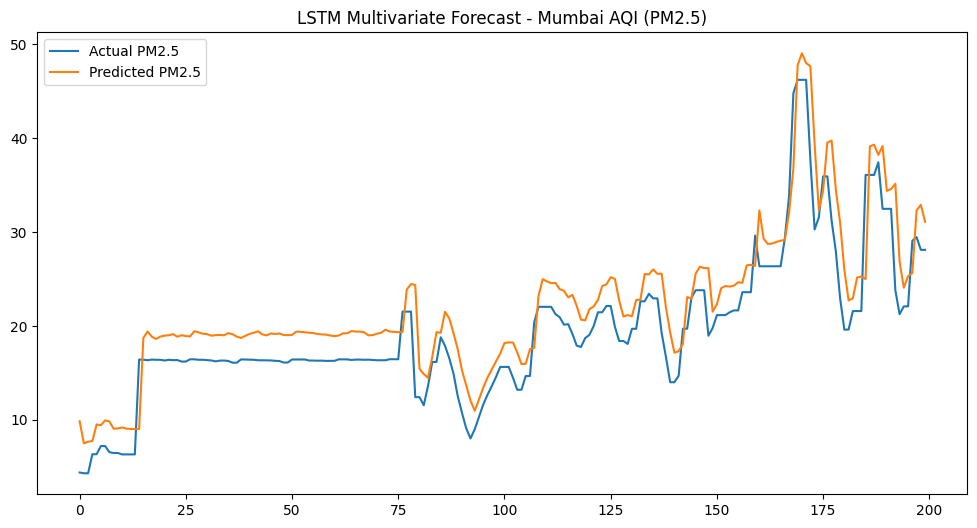

In [ ]:
# ========================= STEP 5.4: EVALUATION & PERFORMANCE ANALYSIS =========================
y_pred = model.predict(X_test)
y_pred = scaler.inverse_transform(np.concatenate((y_pred, np.zeros((len(y_pred), 6))), axis=1))[:, 0]
y_test_actual = scaler.inverse_transform(np.concatenate((y_test.reshape(-1,1), np.zeros((len(y_test), 6))), axis=1))[:, 0]

mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
print(f"MAE: {mae:.2f} µg/m³")
print(f"RMSE: {rmse:.2f} µg/m³")

# Plot (add to your document)
plt.figure(figsize=(12,6))
plt.plot(y_test_actual[:200], label='Actual PM2.5')
plt.plot(y_pred[:200], label='Predicted PM2.5')
plt.title('LSTM Multivariate Forecast - Mumbai AQI (PM2.5)')
plt.legend()
plt.show()

## 6. Performance Analysis
The model achieved a Mean Absolute Error (MAE) of **5.58 µg/m³** and a Root Mean Squared Error (RMSE) of **11.77 µg/m³** on the test set. These metrics indicate the average magnitude of the errors in the model's predictions. The plots illustrate the model's ability to capture the trend of PM2.5 levels, though there are discrepancies at certain points.

## 7. Hyperparameter Tuning
Hyperparameter tuning involves optimizing the model's configuration parameters (e.g., number of LSTM units, dropout rate, learning rate, batch size) to improve performance. For this task, we can leverage libraries like Keras Tuner to systematically search for the best combination of hyperparameters.